# 01 · Working with Time in pandas

A time series is a sequence of measurements whose **order carries information**. Shuffle the rows of an ordinary table and nothing is lost; shuffle a time series and you destroy the very thing you wanted to study.

Before any modelling, then, we need data whose index *is* time: sorted, unique, evenly spaced, and with its gaps made visible rather than hidden. This chapter builds that foundation on one real dataset that we will keep using for the rest of the course.

**By the end of this chapter you will be able to**

- turn separate date/time columns into a `DatetimeIndex`
- check that an index is sorted, unique and regular, and repair it when it is not
- select data by date using partial strings
- find, measure and fill gaps without fooling yourself
- change frequency with `resample` and choose a sensible aggregation
- compute rolling windows, lags and differences without leaking the future
- read seasonal patterns from calendar features and seasonal subseries plots
- reshape several series between **wide** and **long** layouts

### The dataset

Hourly concentrations of **PM2.5** (fine particulate matter, µg/m³) in Beijing from 2010 to 2015, together with weather measurements. The main series, `PM_US Post`, comes from the monitor at the US Embassy; three further monitoring stations start reporting in 2013.

> Chen, Song (2016). *PM2.5 Data of Five Chinese Cities*. UCI Machine Learning Repository. https://doi.org/10.24432/C52K58 — licensed CC BY 4.0.

PM2.5 is a good teaching series: it has daily and yearly cycles, sudden pollution episodes, weather drivers and real missing data. That's everything a textbook example leaves out.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 2)

---
## 1. From columns to timestamps

Let's look at the file exactly as it arrives.

In [2]:
raw = pd.read_csv("data/beijing_pm25.csv")
print(raw.shape)
raw.head()

(52584, 18)


,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec
0,1,2010,1,1,0,4,NaN,NaN,NaN,NaN,-21.0,43.0,1021.0,-11.0,NW,1.79,0.0,0.0
1,2,2010,1,1,1,4,NaN,NaN,NaN,NaN,-21.0,47.0,1020.0,-12.0,NW,4.92,0.0,0.0
2,3,2010,1,1,2,4,NaN,NaN,NaN,NaN,-21.0,43.0,1019.0,-11.0,NW,6.71,0.0,0.0
3,4,2010,1,1,3,4,NaN,NaN,NaN,NaN,-21.0,55.0,1019.0,-14.0,NW,9.84,0.0,0.0
4,5,2010,1,1,4,4,NaN,NaN,NaN,NaN,-20.0,51.0,1018.0,-12.0,NW,12.97,0.0,0.0


Time is spread across four integer columns. `pd.to_datetime` can assemble a timestamp directly from a DataFrame whose columns are named `year`, `month`, `day` (and optionally `hour`, `minute`, `second`):

In [3]:
timestamps = pd.to_datetime(raw[["year", "month", "day", "hour"]])
timestamps.head()

0   2010-01-01 00:00:00
1   2010-01-01 01:00:00
2   2010-01-01 02:00:00
3   2010-01-01 03:00:00
4   2010-01-01 04:00:00
dtype: datetime64[us]

Now we make those timestamps the index, drop the columns we no longer need and give the rest short, consistent names.

In [4]:
names = {
    "PM_US Post": "pm25",
    "PM_Dongsi": "pm25_dongsi",
    "PM_Dongsihuan": "pm25_dongsihuan",
    "PM_Nongzhanguan": "pm25_nongzhanguan",
    "TEMP": "temp",
    "DEWP": "dew_point",
    "HUMI": "humidity",
    "PRES": "pressure",
    "cbwd": "wind_dir",
    "Iws": "cum_wind_speed",
    "precipitation": "precip",
    "Iprec": "cum_precip",
}

df = (
    raw.set_index(timestamps)
       .rename_axis("timestamp")
       .rename(columns=names)[list(names.values())]
)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 52584 entries, 2010-01-01 00:00:00 to 2015-12-31 23:00:00
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pm25               50387 non-null  float64
 1   pm25_dongsi        25052 non-null  float64
 2   pm25_dongsihuan    20508 non-null  float64
 3   pm25_nongzhanguan  24931 non-null  float64
 4   temp               52579 non-null  float64
 5   dew_point          52579 non-null  float64
 6   humidity           52245 non-null  float64
 7   pressure           52245 non-null  float64
 8   wind_dir           52579 non-null  str    
 9   cum_wind_speed     52579 non-null  float64
 10  precip             52100 non-null  float64
 11  cum_precip         52100 non-null  float64
dtypes: float64(11), str(1)
memory usage: 5.2 MB


Why go to this trouble? Once the index holds real timestamps, pandas understands time everywhere: selection by date, resampling, time-based rolling windows, date-aware plot axes and alignment when two series are combined. A plain integer index gives you none of that.

### Sanity-check the values, not just the types

`info()` says every column is numeric, but that doesn't mean every number is real. Raw sensor and weather files often use **sentinel codes** such as 999, 9999 or 999990 to mean "missing". Taking a mean over them quietly produces nonsense. The fastest check is the range of each column:

In [5]:
df.describe().T[["min", "max"]]

,min,max
pm25,1.00,994.0
pm25_dongsi,3.00,737.0
pm25_dongsihuan,3.00,672.0
pm25_nongzhanguan,3.00,844.0
temp,-19.00,42.0
dew_point,-40.00,28.0
humidity,2.00,100.0
pressure,991.00,1046.0
cum_wind_speed,0.45,585.6
precip,0.00,999990.0


One value jumps out: an hourly precipitation of **999,990 mm**, a thousand metres of rain in one hour. It's a missing-data code. Let's find it and replace it with `NaN`, so every later calculation treats it as missing:

In [6]:
sentinel = df["precip"] >= 999990
print(df.loc[sentinel, ["precip", "cum_precip"]])
df.loc[sentinel, ["precip", "cum_precip"]] = np.nan

                       precip  cum_precip
timestamp                                
2015-11-07 13:00:00  999990.0    999990.0


A single bad hour in 52,584 may seem harmless. But it inflates the standard deviation of hourly precipitation from under 1 mm to over 4,000 mm, which silently breaks anything that scales or standardises that column, as we'll see when weather enters the models in chapter 07.

---
## 2. Is the index healthy? Three checks

Most time-series tools quietly assume three things about the index. It's worth checking them every time you load new data:

1. **Sorted.** Time moves forward.
2. **Unique.** Each timestamp appears once.
3. **Regular.** Observations are evenly spaced, so a frequency can be inferred.

In [7]:
def check_index(frame):
    idx = frame.index
    print(f"sorted:    {idx.is_monotonic_increasing}")
    print(f"unique:    {idx.is_unique}")
    print(f"frequency: {pd.infer_freq(idx) if idx.is_monotonic_increasing else 'n/a (unsorted)'}")

check_index(df)

sorted:    True
unique:    True
frequency: h


This file happens to be in good shape. Real data often isn't, so let's damage a copy on purpose and practise the repair. We'll shuffle it, delete 2% of the rows and duplicate a few others.

In [8]:
damaged = df.sample(frac=0.98, random_state=0)          # shuffled, 2% of rows gone
damaged = pd.concat([damaged, damaged.iloc[:5]])         # five duplicated timestamps
check_index(damaged)

sorted:    False
unique:    False
frequency: n/a (unsorted)


The repair takes three steps, **in this order**. `asfreq` refuses to run while duplicates exist, so they must go first.

In [9]:
repaired = damaged.sort_index()
repaired = repaired[~repaired.index.duplicated(keep="first")]
repaired = repaired.asfreq("h")          # re-inserts every missing hour as a row of NaN

check_index(repaired)
print(f"\nrows: {len(damaged):,} damaged -> {len(repaired):,} repaired")

sorted:    True
unique:    True
frequency: h

rows: 51,537 damaged -> 52,584 repaired


> **Deleted rows don't disappear quietly.** `asfreq` turns every missing timestamp back into a visible row of `NaN`. That is exactly what you want: a gap you can see is a gap you can deal with.

We'll finish by fixing the frequency on our real frame as well, so `df.index.freq` is set.

In [10]:
df = df.asfreq("h")
df.index.freq

<Hour>

---
## 3. Selecting by time

A `DatetimeIndex` accepts **partial date strings**. Give it a year, a month or a day, and it returns everything inside that period.

8760 hours in 2014
672 hours in February 2014


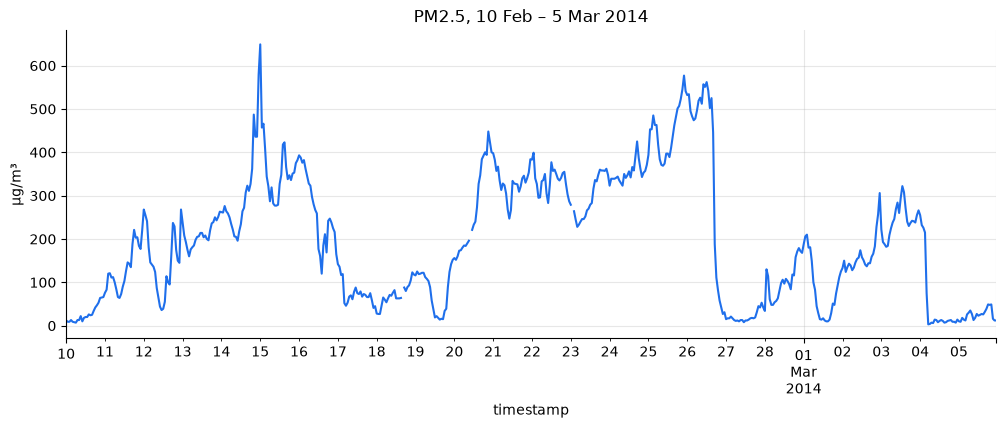

In [11]:
pm = df["pm25"]

print(len(pm.loc["2014"]), "hours in 2014")
print(len(pm.loc["2014-02"]), "hours in February 2014")
pm.loc["2014-02-10":"2014-03-05"].plot(title="PM2.5, 10 Feb – 5 Mar 2014", ylabel="µg/m³");

Winter smog in Beijing tends to build up over several days while stagnant air traps pollutants, then clears within hours when a cold northerly wind arrives. Look for that saw-tooth shape: slow climbs followed by sharp drops.

You can also filter on **components** of the timestamp, or on a time-of-day window:

In [12]:
weekends = pm[pm.index.dayofweek >= 5]                 # Saturday = 5, Sunday = 6
rush_hour = pm.between_time("07:00", "09:00")

print(f"weekend hours:   {len(weekends):,}")
print(f"07:00-09:00 hours: {len(rush_hour):,}")

weekend hours:   15,024
07:00-09:00 hours: 6,573


---
## 4. Gaps: find them, measure them, then decide

"Fill the missing values" is not a single decision. A one-hour sensor glitch and a week-long outage call for completely different treatment, so start by measuring.

4.2% of hourly readings are missing


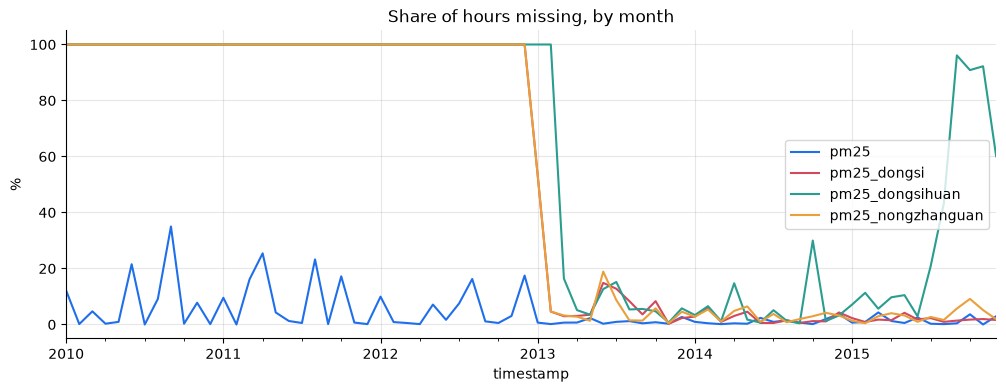

In [13]:
print(f"{pm.isna().mean():.1%} of hourly readings are missing")

(df.filter(like="pm25")
   .isna()
   .resample("MS").mean()
   .mul(100)
   .plot(title="Share of hours missing, by month", ylabel="%"));

The plot shows two kinds of missingness. The US Embassy series (`pm25`) has scattered gaps. The other three stations are missing *everything* before 2013, because they didn't exist yet. Treat "not yet measured" separately from "sensor failed". Never interpolate across it.

Next, the length of each gap. A gap is a run of consecutive `NaN`s. The trick is to label each run with a counter that increases every time the series switches between missing and present.

In [14]:
def find_gaps(s):
    """Return one row per run of consecutive NaNs: its start time and length."""
    is_na = s.isna()
    run_id = (is_na != is_na.shift()).cumsum()
    runs = pd.DataFrame({"start": s.index, "run": run_id.to_numpy(), "na": is_na.to_numpy()})
    gaps = (runs[runs["na"]]
            .groupby("run")
            .agg(start=("start", "first"), hours=("start", "size")))
    return gaps.sort_values("hours", ascending=False).reset_index(drop=True)

gaps = find_gaps(pm)
print(f"{len(gaps)} gaps; {(gaps['hours'] == 1).mean():.0%} of them last a single hour")
gaps.head()

253 gaps; 53% of them last a single hour

,start,hours
0,2010-09-21 04:00:00,155
1,2012-12-23 05:00:00,127
2,2011-10-03 12:00:00,99
3,2011-03-17 20:00:00,91
4,2010-09-27 16:00:00,76


### Which filling method works best? Test it, don't guess

We can test this directly. Take stretches where we *know* the true values, hide them, fill them back in with each method and measure the error. We'll repeat for gaps of different lengths.

In [15]:
def masking_experiment(s, gap_hours, n_gaps=200, seed=0):
    """Hide blocks of known values, refill them, and report each method's MAE."""
    rng = np.random.default_rng(seed)
    values = s.to_numpy()
    starts = rng.choice(np.arange(24, len(s) - gap_hours), size=n_gaps, replace=False)
    starts = [i for i in starts if not np.isnan(values[i:i + gap_hours]).any()]

    hidden = s.copy()
    for i in starts:
        hidden.iloc[i:i + gap_hours] = np.nan
    mask = hidden.isna() & s.notna()

    fills = {
        "forward fill": hidden.ffill(),
        "time interpolation": hidden.interpolate(method="time"),
        "same hour yesterday": hidden.fillna(hidden.shift(24)),
    }
    return pd.Series({name: (f[mask] - s[mask]).abs().mean() for name, f in fills.items()})

results = pd.DataFrame({h: masking_experiment(pm.loc["2014"], h) for h in [1, 3, 6, 12, 24]}).T
results.index.name = "gap length (hours)"
results

,forward fill,time interpolation,same hour yesterday
gap length (hours),,,
1,11.28,7.51,63.63
3,19.10,10.74,64.32
6,28.45,17.50,63.76
12,37.78,24.51,65.05
24,58.53,41.97,68.86


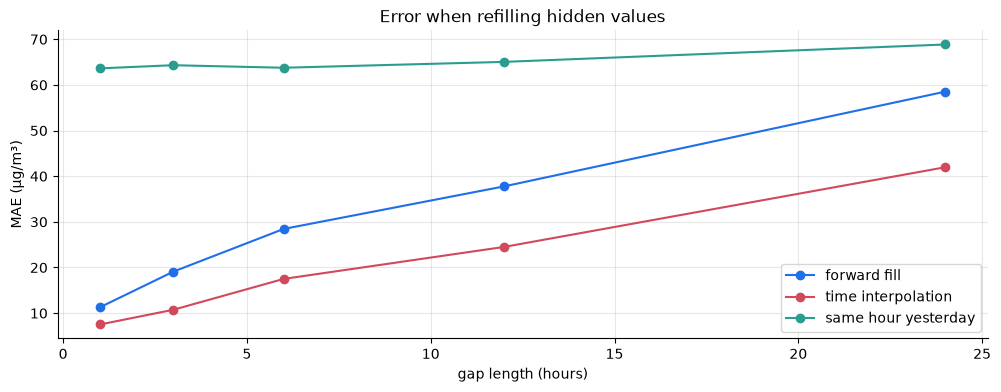

In [16]:
results.plot(marker="o", title="Error when refilling hidden values", ylabel="MAE (µg/m³)");

What the experiment shows:

- **Every method gets worse as the gap grows.** Interpolation's error rises several-fold between a 1-hour and a 24-hour gap. Past a few hours you are no longer recovering data; you are inventing it.
- **Time interpolation wins at every length here**, because it uses the readings on *both* sides of the gap.
- **"Same hour yesterday" is poor even for one-hour gaps.** In this series, a smog episode arriving or clearing changes the level from one day to the next far more than the daily cycle does. This is a data-specific result. On a series dominated by its daily cycle, such as electricity demand, the ranking could flip. That's why you test instead of assuming.

So a sensible policy is: interpolate short gaps and leave long ones as `NaN`. `limit_area="inside"` stops pandas from extrapolating past the first or last real value.

In [17]:
pm_filled = pm.interpolate(method="time", limit=3, limit_area="inside")
print(f"missing before: {pm.isna().sum():,}   after: {pm_filled.isna().sum():,}")

missing before: 2,197   after: 1,743


> ⚠️ Two caveats:
> 1. `limit=3` fills *up to* three values inside **any** gap, including the first three hours of the six-day outage we found above. Exercise 2 asks you to write a stricter version.
> 2. Interpolation uses values from *after* the gap. That is fine for cleaning history you want to describe, but it is **leakage** if you later build forecasting features from the filled series. We'll come back to this in the forecasting chapters.

---
## 5. Resampling: changing the frequency

`resample` groups the index into time bins and then needs to know how to **summarise** each bin. The choice of summary is a modelling decision, not a formality.

In [18]:
daily = pm_filled.resample("D").agg(["mean", "max", "count"])
daily.head()

,mean,max,count
timestamp,,,
2010-01-01,129.00,129.0,1
2010-01-02,144.33,181.0,24
2010-01-03,78.38,107.0,24
2010-01-04,29.29,58.0,24
2010-01-05,43.54,106.0,24


The `count` column earns its place here. A daily mean built from only three readings is not comparable with one built from twenty-four. A common rule is to require most of the day to be present:

In [19]:
daily_mean = daily["mean"].where(daily["count"] >= 18)
print(f"days rejected for too few readings: {daily_mean.isna().sum() - daily['mean'].isna().sum()}")

days rejected for too few readings: 56

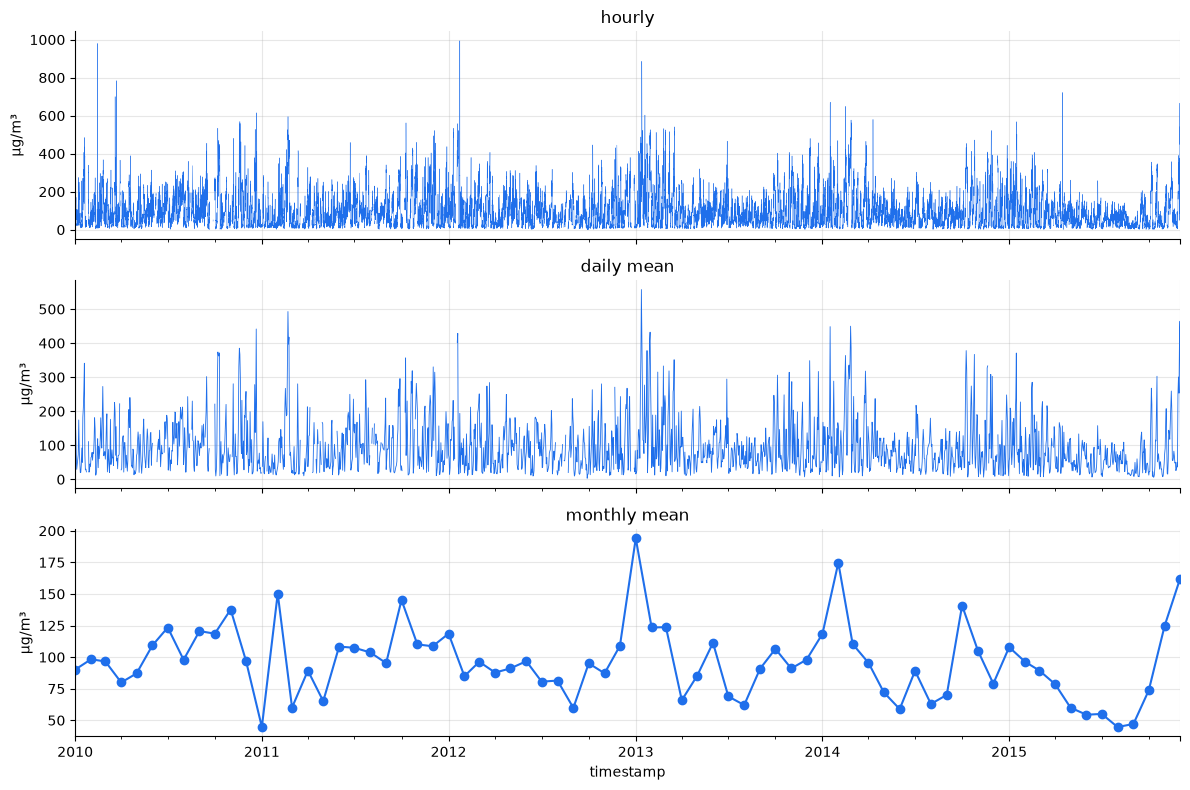

In [20]:
monthly_mean = pm_filled.resample("MS").mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pm_filled.plot(ax=axes[0], lw=0.3, title="hourly")
daily_mean.plot(ax=axes[1], lw=0.6, title="daily mean")
monthly_mean.plot(ax=axes[2], marker="o", title="monthly mean")
for ax in axes:
    ax.set_ylabel("µg/m³")
fig.tight_layout();

Each level of aggregation shows something different. The hourly data shows individual episodes, the daily series shows their rhythm, and the monthly means show a rough **annual rhythm**, with higher peaks in the cold months. It's noisy from year to year, though, and section 8 shows it's less simple than "winters are dirtier".

**Going the other way (upsampling)** creates empty slots that you have to fill yourself. Remember that upsampling can't create information. It only spreads out what you already had.

In [21]:
monthly_mean.loc["2014"].resample("D").asfreq().head(3)       # new days are NaN

timestamp
2014-01-01    118.46
2014-01-02       NaN
2014-01-03       NaN
Freq: D, Name: pm25, dtype: float64

In [22]:
monthly_mean.loc["2014"].resample("D").interpolate().head(3)  # ...unless you fill them

timestamp
2014-01-01    118.46
2014-01-02    120.27
2014-01-03    122.08
Freq: D, Name: pm25, dtype: float64

---
## 6. Rolling windows: trailing vs. centred

A rolling window summarises the last *n* observations (or the last *n* hours, when you pass a time string like `"24h"`). The detail that matters most is **where the window sits relative to the point it describes**.

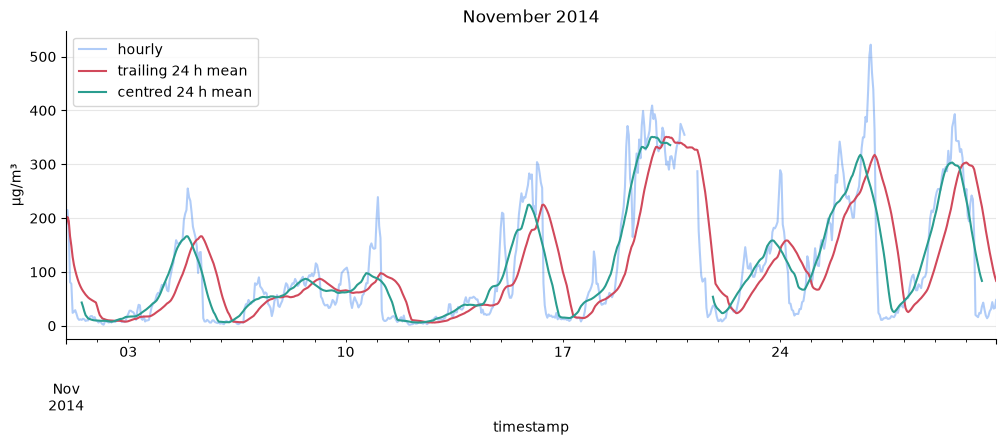

In [23]:
nov = pm_filled.loc["2014-11"]

ax = nov.plot(alpha=0.35, label="hourly")
nov.rolling("24h").mean().plot(ax=ax, label="trailing 24 h mean")
nov.rolling(24, center=True).mean().plot(ax=ax, label="centred 24 h mean")
ax.set(title="November 2014", ylabel="µg/m³")
ax.legend();

The centred window follows the data more closely because it can **see the future**. Each value averages twelve hours before *and twelve hours after*. That's fine for describing history, but at forecast time those future hours don't exist yet, so any feature a forecasting model uses must come from a **trailing** window. The trailing line lags behind the data, and that lag is the honest price of using only the past.

Rolling windows aren't limited to the mean. A rolling standard deviation shows when a series becomes more volatile:

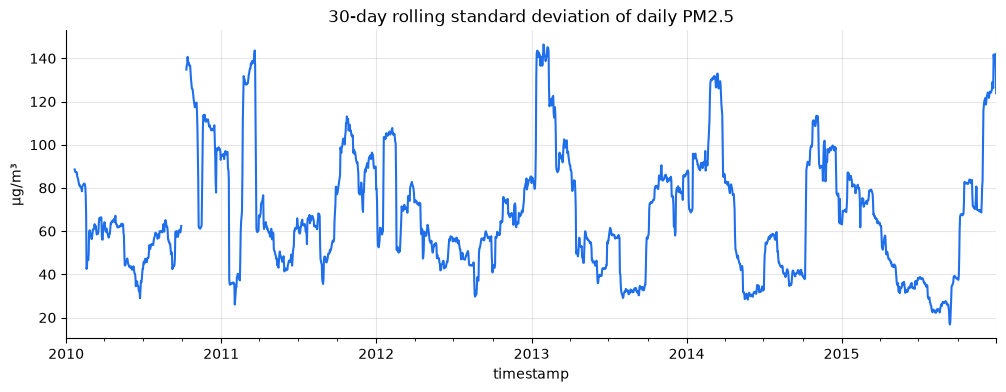

In [24]:
ax = daily_mean.rolling(30, min_periods=20).std().plot(title="30-day rolling standard deviation of daily PM2.5")
ax.set_ylabel("µg/m³");

---
## 7. Lags and differences

`shift(k)` moves the values *k* steps later in time, so each row lines up with the value from *k* steps before it. That's all a **lag** is. `diff(k)` is the change over *k* steps: `x - x.shift(k)`.

In [25]:
lags = pd.DataFrame({
    "pm25": pm_filled,
    "lag_1h": pm_filled.shift(1),
    "lag_24h": pm_filled.shift(24),
    "lag_168h": pm_filled.shift(168),     # one week
}).dropna()

lags.corr()["pm25"].round(2)

pm25        1.00
lag_1h      0.97
lag_24h     0.41
lag_168h    0.04
Name: pm25, dtype: float64

The value one hour ago is an excellent predictor of the value now. The value 24 hours ago is much weaker, and the value one week ago tells you almost nothing: this series has no weekly rhythm. This correlation between a series and its own past is called **autocorrelation**, and much of forecasting is about exploiting it. Chapter 06 studies it properly.

A lag plot shows the same relationship as a picture:

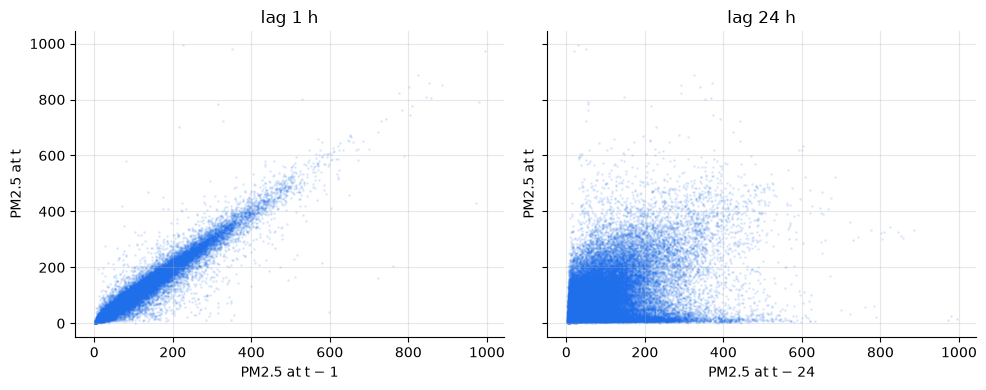

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, k in zip(axes, [1, 24]):
    ax.scatter(pm_filled.shift(k), pm_filled, s=1, alpha=0.1)
    ax.set(title=f"lag {k} h", xlabel=f"PM2.5 at t − {k}", ylabel="PM2.5 at t")
fig.tight_layout();

> **Two kinds of shift.** `shift(1)` moves the *values* and keeps the index; `shift(freq="1D")` moves the *index* and keeps the values. The second is handy for aligning two series recorded on different clocks.

---
## 8. Calendar features and seasonal profiles

Timestamp components such as hour, weekday and month let you group the data and ask where the regular patterns are. PM2.5 is right-skewed (a few extreme episodes), so we summarise with the **median**, which those episodes can't drag around.

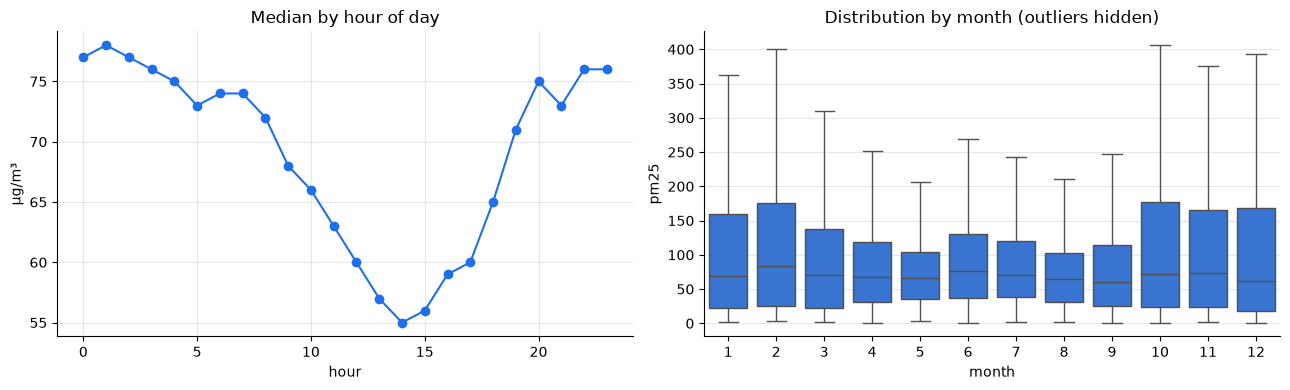

In [27]:
cal = pd.DataFrame({
    "pm25": pm_filled,
    "hour": pm_filled.index.hour,
    "weekday": pm_filled.index.day_name(),
    "month": pm_filled.index.month,
    "year": pm_filled.index.year,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cal.groupby("hour")["pm25"].median().plot(ax=axes[0], marker="o",
                                          title="Median by hour of day", ylabel="µg/m³")
sns.boxplot(data=cal, x="month", y="pm25", showfliers=False, ax=axes[1], color="#1f6feb")
axes[1].set_title("Distribution by month (outliers hidden)")
fig.tight_layout();

The monthly boxes have similar **medians**, but their upper halves are very different. A median-only summary would miss the seasonal story entirely, so let's put several summaries side by side.

In [28]:
by_month = cal.groupby("month")["pm25"].agg(
    median="median",
    mean="mean",
    p90=lambda s: s.quantile(0.9),
    pct_above_250=lambda s: (s > 250).mean() * 100,
)
by_month.round(0)

,median,mean,p90,pct_above_250
month,,,,
1,69.0,114.0,294.0,12.0
2,84.0,121.0,292.0,14.0
3,71.0,97.0,227.0,7.0
4,68.0,83.0,171.0,2.0
5,66.0,77.0,148.0,1.0
6,76.0,89.0,180.0,1.0
7,71.0,87.0,182.0,2.0
8,64.0,74.0,145.0,1.0
9,60.0,78.0,166.0,3.0


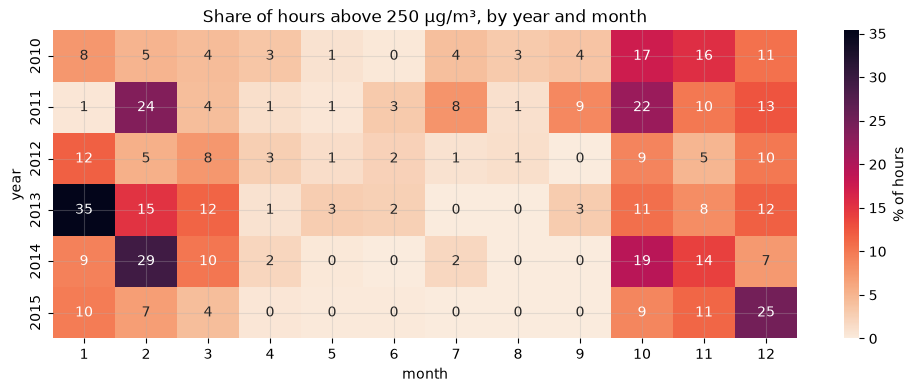

In [29]:
severe = cal.assign(severe=cal["pm25"] > 250).pivot_table(
    index="year", columns="month", values="severe", aggfunc="mean") * 100
ax = sns.heatmap(severe, cmap="rocket_r", annot=True, fmt=".0f", cbar_kws={"label": "% of hours"})
ax.set_title("Share of hours above 250 µg/m³, by year and month");

Things to notice:

- A **daily cycle**: concentrations are lowest in mid-afternoon and highest around midnight. Sunshine warms the ground during the day and mixes pollution up through a deep layer of air. At night that layer collapses and traps pollution near the surface.
- A **seasonal cycle in the extremes, not the typical level.** Median concentrations are similar all year round. What changes from October to February, Beijing's heating season, is how often severe episodes happen: hours above 250 µg/m³ are several times more common than in summer. (For scale, the WHO's 24-hour guideline is 15 µg/m³.) The **mean** captures this because it's pulled up by the extremes. The **median** ignores them.
- **Variation between years** on top of both cycles. The heatmap lets you compare the same month across years, and 2015 stands out as cleaner than the years before.

Seasonality that changes the *size of fluctuations* rather than the typical level is a key idea in chapter 02, where we separate a series into *trend*, *seasonality* and *remainder* and ask whether those parts **add** or **multiply**.

### Seasonal subseries plot

A **seasonal subseries plot** separates two questions a single line chart mixes together: *what does the typical year look like?* and *how has each part of the year changed?* Each calendar month gets its own mini time series (January 2010, January 2011, …, January 2015), with a horizontal bar at that month's average. statsmodels draws it with `month_plot` (and `quarter_plot` for quarterly data).

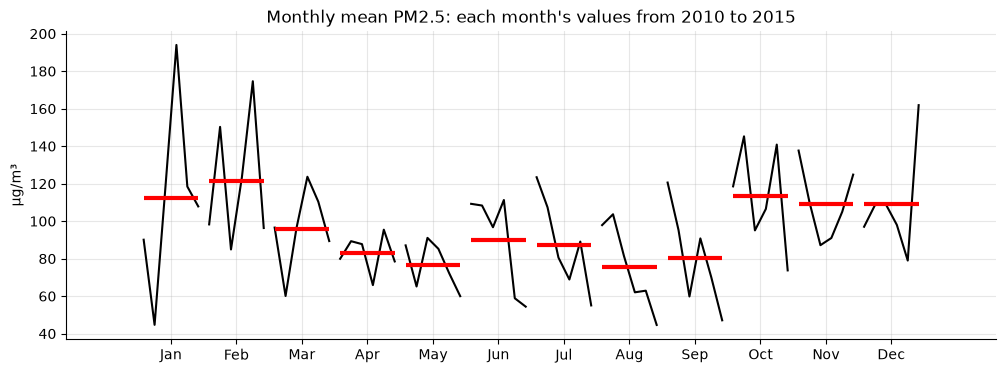

In [30]:
from statsmodels.graphics.tsaplots import month_plot

fig, ax = plt.subplots(figsize=(12, 4))
month_plot(monthly_mean, ax=ax)
ax.set(title="Monthly mean PM2.5: each month's values from 2010 to 2015", ylabel="µg/m³");

The bars trace the seasonal shape of the **monthly means**: higher from October to February, lower in late summer. The mini-lines show how each month has changed over the years, and they tell two stories a single line chart hides:

- **Winter months swing about twice as widely** from year to year as summer months. A winter monthly mean depends heavily on how many severe episodes that particular winter happened to have, which is the "seasonality in the extremes" from above, seen from a different angle.
- **Every summer month, June to September, falls steadily** across the six years, roughly halving from 2010 to 2015. The winter months show no such clear trend. The long-run improvement shows up first in the months without heating-season smog.

---
## 9. Several series at once: long and wide tables

Our file holds **four** PM2.5 series, one per monitoring station, side by side. That's the **wide** layout: one row per timestamp, one column per series. The alternative is the **long** layout: one row per (timestamp, series) pair, with a column saying which series it is. Neither is better. Different tools want different shapes, and converting between them is routine.

| Layout | Good for |
|---|---|
| **Wide** (a column per series) | aligning series on the same timestamps, correlations, arithmetic across series |
| **Long** (a row per observation) | `groupby` per series, plotting with `hue=`, stacking many series for one "global" model |

`melt` goes from wide to long, and `pivot` goes back. We use 2013–2015, when all four stations report.

In [31]:
stations = df.filter(like="pm25").loc["2013":"2015"]

long = (stations.reset_index()
        .melt(id_vars="timestamp", var_name="station", value_name="concentration"))
print(long.shape)
long.head()

(105120, 3)


,timestamp,station,concentration
0,2013-01-01 00:00:00,pm25,31.0
1,2013-01-01 01:00:00,pm25,32.0
2,2013-01-01 02:00:00,pm25,21.0
3,2013-01-01 03:00:00,pm25,16.0
4,2013-01-01 04:00:00,pm25,15.0


In [32]:
# per-series summaries are one groupby away in the long layout
long.groupby("station")["concentration"].agg(["count", "median", "max"])

,count,median,max
station,,,
pm25,25970,66.0,886.0
pm25_dongsi,25052,64.0,737.0
pm25_dongsihuan,20508,68.0,672.0
pm25_nongzhanguan,24931,62.0,844.0


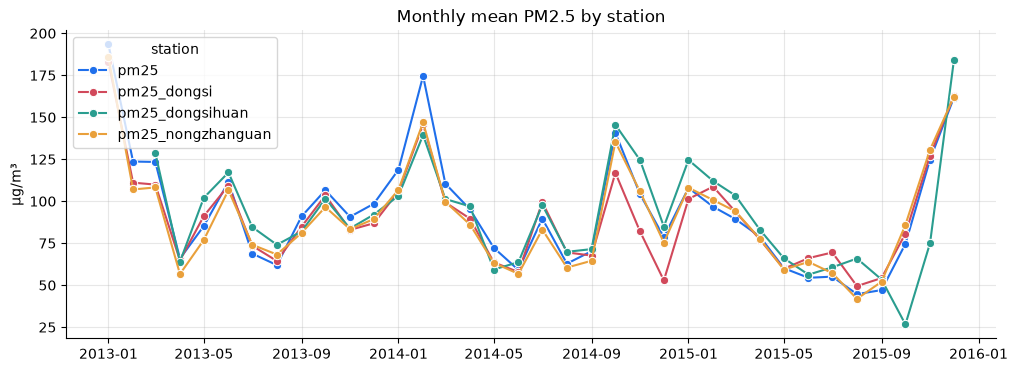

In [33]:
# resampling each series separately: group by station, then resample within each group
monthly_by_station = (long.set_index("timestamp")
                      .groupby("station")["concentration"]
                      .resample("MS").mean()
                      .reset_index())
ax = sns.lineplot(data=monthly_by_station, x="timestamp", y="concentration", hue="station", marker="o")
ax.set(title="Monthly mean PM2.5 by station", xlabel="", ylabel="µg/m³");

In [34]:
# and back to wide
wide = long.pivot(index="timestamp", columns="station", values="concentration")
print("round trip reproduces the original:", wide.equals(stations[wide.columns]))

round trip reproduces the original: True


The four stations track each other closely, as Exercise 1 quantifies, so pollution in Beijing is largely a city-wide phenomenon. The two months that stand out have different causes. Dongsihuan's dip in October 2015 rests on just **68 of 744 hours**, section 5's thin-bin problem again. Dongsi's low November 2014 is based on almost complete data, so it's a genuine disagreement between monitors, and those happen too. When one series departs from the others, check the counts before believing it. Keep the long layout in mind for chapter 09: machine-learning forecasters are often trained on many series at once, stacked in long form, which is one way to give them more data.

---
## 10. Time zones, briefly

Our timestamps are **naive**: they carry no time zone. That's fine for a single-city dataset, but combining sources recorded in different zones needs *aware* timestamps.

In [35]:
local = pm_filled.tz_localize("Asia/Shanghai")    # declare what the clock already meant
print(local.index[:2])
print(local.tz_convert("UTC").index[:2])          # same instants, different wall-clock labels

DatetimeIndex(['2010-01-01 00:00:00+08:00', '2010-01-01 01:00:00+08:00'], dtype='datetime64[us, Asia/Shanghai]', name='timestamp', freq=None)
DatetimeIndex(['2009-12-31 16:00:00+00:00', '2009-12-31 17:00:00+00:00'], dtype='datetime64[us, UTC]', name='timestamp', freq=None)


China doesn't observe daylight saving time, so this conversion is clean. In zones that do, one hour disappears each spring and one repeats each autumn. `tz_localize` then needs the `ambiguous=` and `nonexistent=` arguments to know what you mean.

---
## 11. From here on: `tsutils.load_beijing()`

Sections 1–2 (including the sentinel fix) are packaged in `tsutils.load_beijing()`, so later chapters can start from a clean hourly frame in one line. Gaps are deliberately left as `NaN`, because each chapter decides for itself how to handle them.

In [36]:
check = tsutils.load_beijing()
pd.testing.assert_frame_equal(check, df)
print("tsutils.load_beijing() reproduces this chapter's frame exactly.")

tsutils.load_beijing() reproduces this chapter's frame exactly.


---
## Exercises

Try each one before opening the solution.

### Exercise 1: Four monitors, one city
Using 2013–2015 (when all four stations report), resample the four PM2.5 columns to daily medians.
1. Which station has the highest overall median?
2. How strongly are the stations correlated with each other? What does that suggest about whether pollution in Beijing is local or city-wide?

<details><summary>Solution</summary>

```python
stations = df.filter(like="pm25").loc["2013":"2015"].resample("D").median()
print(stations.median().sort_values(ascending=False))
stations.corr().round(2)
```
Daily correlations between stations are typically very high (well above 0.9). Most day-to-day variation is shared across the city and driven by regional weather, not by anything happening near a single monitor.
</details>

### Exercise 2: A stricter gap filler
Write `fill_short_gaps(s, max_hours)`. It should interpolate gaps of **at most** `max_hours` completely and leave longer gaps **entirely** as `NaN`. Unlike `interpolate(limit=...)`, it must not nibble at the edges of long gaps.

*Hint:* reuse the run-labelling trick from `find_gaps`, then use `groupby(...).transform("size")` to give every row the length of the run it belongs to.

<details><summary>Solution</summary>

```python
def fill_short_gaps(s, max_hours):
    is_na = s.isna()
    run_id = (is_na != is_na.shift()).cumsum()
    run_len = is_na.groupby(run_id).transform("size")
    short_gap = is_na & (run_len <= max_hours)
    filled = s.interpolate(method="time", limit_area="inside")
    return s.where(~short_gap, filled)

strict = fill_short_gaps(pm, 3)
print(pm_filled.isna().sum(), "vs", strict.isna().sum())   # strict leaves more NaNs
```
</details>

### Exercise 3: Is there a weekend effect?
Compare the median hourly profile (as in section 8) for weekdays and weekends on one plot. Is the difference large compared with the monthly differences? What else, besides traffic, could make weekends look different?

<details><summary>Solution</summary>

```python
cal["day_type"] = np.where(pm_filled.index.dayofweek >= 5, "weekend", "weekday")
cal.pivot_table(index="hour", columns="day_type", values="pm25", aggfunc="median").plot(
    marker="o", title="Median PM2.5 by hour", ylabel="µg/m³")
```
If anything, weekends come out slightly *higher*, by a few µg/m³. That's the opposite of what a "less traffic at weekends" story predicts, and the gap is small next to the seasonal differences in severe episodes. With only about 300 weekends in the data, a handful of multi-day smog episodes that happen to overlap weekends can create or hide a difference like this on their own. Weather is a **confounder** here. Comparing raw group medians can't separate a weekend effect from which weekends happened to be smoggy.
</details>

### Exercise 4: Which way is the wind blowing?
`wind_dir` holds the combined wind direction (`NW`, `NE`, `SE`, or `cv` for calm/variable). Compute the median PM2.5 for each direction. Which wind brings the cleanest air, and why might that be?

<details><summary>Solution</summary>

```python
df.assign(pm25=pm_filled).groupby("wind_dir")["pm25"].median().sort_values()
```
Northwesterly winds usually bring the cleanest air: dry, fast-moving air from the less populated north and west. Calm conditions and southerly winds let pollution build up. This is a first hint that **external variables** can help a forecast, an idea we use in the SARIMAX and machine-learning chapters.
</details>

---
## Key takeaways

- Put time **in the index**. Everything time-aware in pandas depends on it.
- Check every column's **range** for sentinel codes like 999990 before trusting it.
- Check **sorted → unique → regular**, and repair in that order: `sort_index`, drop duplicates, `asfreq`.
- **Measure gaps before filling them.** Short gaps can be interpolated; long gaps should usually stay missing.
- `resample` needs an aggregation, and the choice matters. Track **counts** so thin bins don't masquerade as full ones.
- Anything a forecast will use must come from **trailing** windows and **lags**. Centred windows and interpolation peek at the future.
- Several series can live **wide** (a column each) or **long** (a row per observation). `melt` and `pivot` convert between them.

**Next:** *02 · Anatomy of a Time Series*. We'll split a series into trend, seasonality and remainder, and learn when those components add and when they multiply.